# Milestone 01 — Data Prep & Baseline
**Project:** Customer Churn Prediction (Telco) &nbsp;|&nbsp; **Task type:** binary classification



In [1]:
import sys
from pathlib import Path

# Make the `src/` package importable whether the notebook is launched from notebooks/ or the repo root
ROOT = Path.cwd()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import set_config
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.model_selection import train_test_split

from src.config import ID_COL, RANDOM_STATE, TARGET, TEST_SIZE
from src.data_preparation import clean, load_raw, make_xy, save_processed
from src.evaluation import cross_validate_on_train, evaluate_on, plot_confusion_matrix, plot_roc
from src.preprocessing import (
    build_dummy_baseline,
    build_logistic_baseline,
    build_preprocessor,
    split_column_types,
)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)
set_config(display="diagram")
print("Setup complete. Random seed:", RANDOM_STATE)

Setup complete. Random seed: 42


## 1. Problem Definition

| Item | Definition |
| --- | --- |
| Selected problem | Customer churn prediction |
| Problem type | **Binary classification** (churn = 1, stays = 0) |
| Business context | A telecom provider wants to identify customers likely to leave so retention offers can be targeted, since keeping a customer is usually cheaper than acquiring a new one |
| ML objective | Learn a function from customer account/service attributes to the probability that the customer churns |
| Target variable | `Churn` (`Yes`/`No` in the raw file, encoded to 1/0 in `y`) |
| Positive class | Churn (the class the business cares about finding) |

**Assumption (technical):** the recorded attributes are known *before* the churn outcome, so they can be used at prediction time.

## 2. Dataset Overview

* **Name:** Telco Customer Churn (IBM sample dataset)
* **Source:** public Kaggle listing "Telco Customer Churn", file `WA_Fn-UseC_-Telco-Customer-Churn.csv` (download instructions in `README.md`)
* **Expected structure (per public documentation, confirm against your file):** one row per customer, an ID column, demographic fields
  (`gender`, `SeniorCitizen`, `Partner`, `Dependents`), account fields (`tenure`, `Contract`, `PaperlessBilling`, `PaymentMethod`,
  `MonthlyCharges`, `TotalCharges`), service fields (`PhoneService`, `MultipleLines`, `InternetService`, `OnlineSecurity`, `OnlineBackup`,
  `DeviceProtection`, `TechSupport`, `StreamingTV`, `StreamingMovies`) and the target `Churn`.
* **Feature types:** a few numeric (`tenure`, `MonthlyCharges`, `TotalCharges`), the rest categorical/binary.



In [2]:
raw = load_raw()
print("Rows, columns:", raw.shape)
raw.head()

Rows, columns: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

## 3. Exploratory Data Analysis

### 3.1 Structure, types and summary statistics

In [4]:
raw.describe().T

,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7043.0,0.162147,0.368612,0.00,0.0,0.00,0.00,1.00
tenure,7043.0,32.371149,24.559481,0.00,9.0,29.00,55.00,72.00
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.5,70.35,89.85,118.75


In [5]:
raw.describe(exclude="number").T

,count,unique,top,freq
customerID,7043,7043,7590-VHVEG,1
gender,7043,2,Male,3555
Partner,7043,2,No,3641
Dependents,7043,2,No,4933
PhoneService,7043,2,Yes,6361
MultipleLines,7043,3,No,3390
InternetService,7043,3,Fiber optic,3096
OnlineSecurity,7043,3,No,3498
OnlineBackup,7043,3,No,3088
DeviceProtection,7043,3,No,3095


### 3.2 Missing values, duplicates, unique values

In [6]:
# Count both real NaNs and blank / whitespace-only strings (which isna() does NOT catch)
text_cols = raw.select_dtypes(exclude="number").columns
blank_counts = {c: int((raw[c].astype(str).str.strip() == "").sum()) for c in text_cols}
missing = pd.DataFrame({
    "nan_count": raw.isna().sum(),
    "blank_string_count": pd.Series(blank_counts),
}).fillna(0).astype(int)

issues = missing[(missing > 0).any(axis=1)]
print("Columns with NaN or blank values:", len(issues))
issues

Columns with NaN or blank values: 1


,nan_count,blank_string_count
TotalCharges,0,11


In [7]:
print("Duplicate rows:", raw.duplicated().sum())
print("Duplicate customer IDs:", raw[ID_COL].duplicated().sum())
raw.nunique().sort_values()

Duplicate rows: 0
Duplicate customer IDs: 0


gender                 2
SeniorCitizen          2
Partner                2
Dependents             2
PhoneService           2
PaperlessBilling       2
Churn                  2
MultipleLines          3
TechSupport            3
StreamingTV            3
OnlineBackup           3
DeviceProtection       3
StreamingMovies        3
Contract               3
OnlineSecurity         3
InternetService        3
PaymentMethod          4
tenure                73
MonthlyCharges      1585
TotalCharges        6531
customerID          7043
dtype: int64

### 3.3 Investigating `TotalCharges`

In [8]:
print("TotalCharges dtype:", raw["TotalCharges"].dtype)
tc_numeric = pd.to_numeric(raw["TotalCharges"], errors="coerce")
unparsable = raw[tc_numeric.isna()]
print("Rows where TotalCharges is not a valid number:", len(unparsable))
unparsable[[ID_COL, "tenure", "MonthlyCharges", "TotalCharges", TARGET]]

TotalCharges dtype: str
Rows where TotalCharges is not a valid number: 11


,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,,No
753,3115-CZMZD,0,20.25,,No
936,5709-LVOEQ,0,80.85,,No
1082,4367-NUYAO,0,25.75,,No
1340,1371-DWPAZ,0,56.05,,No
3331,7644-OMVMY,0,19.85,,No
3826,3213-VVOLG,0,25.35,,No
4380,2520-SGTTA,0,20.00,,No
5218,2923-ARZLG,0,19.70,,No
6670,4075-WKNIU,0,73.35,,No


### 3.4 Target distribution

,count,share
Churn,,
No,5174,0.735
Yes,1869,0.265


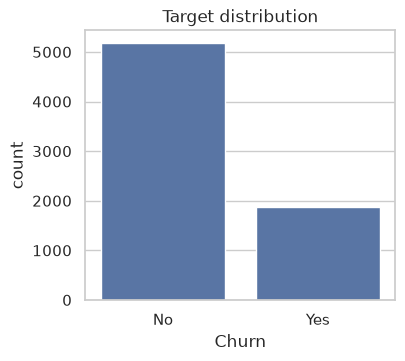

In [9]:
counts = raw[TARGET].value_counts()
share = raw[TARGET].value_counts(normalize=True).round(3)
display(pd.DataFrame({"count": counts, "share": share}))

fig, ax = plt.subplots(figsize=(4, 3.5))
sns.countplot(data=raw, x=TARGET, order=["No", "Yes"], ax=ax)
ax.set_title("Target distribution")
plt.show()

### 3.5 Numerical features

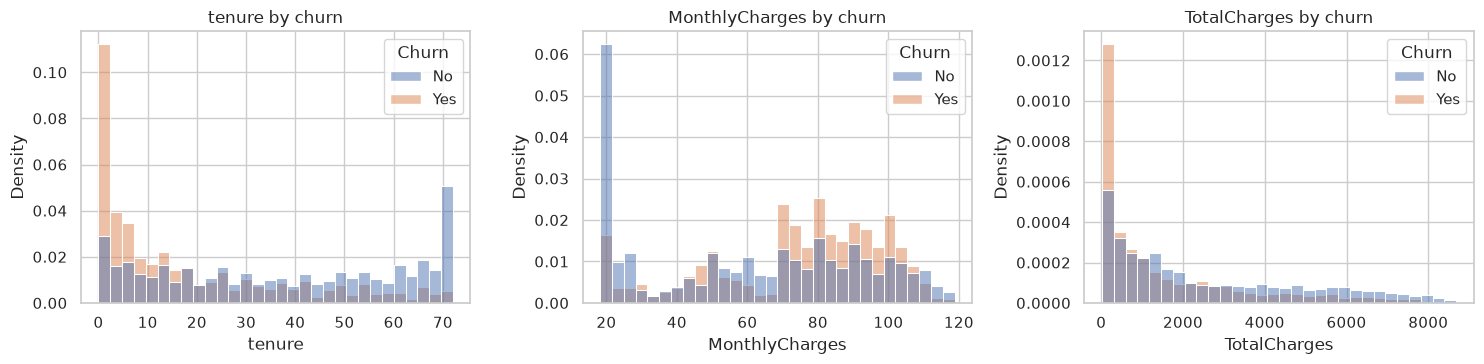

In [10]:
# EDA-only frame: numeric TotalCharges and a 0/1 target flag for grouping
eda = raw.copy()
eda["TotalCharges"] = pd.to_numeric(eda["TotalCharges"], errors="coerce")
eda["churn_flag"] = (eda[TARGET] == "Yes").astype(int)
if pd.api.types.is_numeric_dtype(eda["SeniorCitizen"]):
    eda["SeniorCitizen"] = eda["SeniorCitizen"].map({0: "No", 1: "Yes"})

num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]

fig, axes = plt.subplots(1, 3, figsize=(15, 3.8))
for ax, col in zip(axes, num_cols):
    sns.histplot(data=eda, x=col, hue=TARGET, bins=30, stat="density", common_norm=False, ax=ax)
    ax.set_title(f"{col} by churn")
plt.tight_layout()
plt.show()

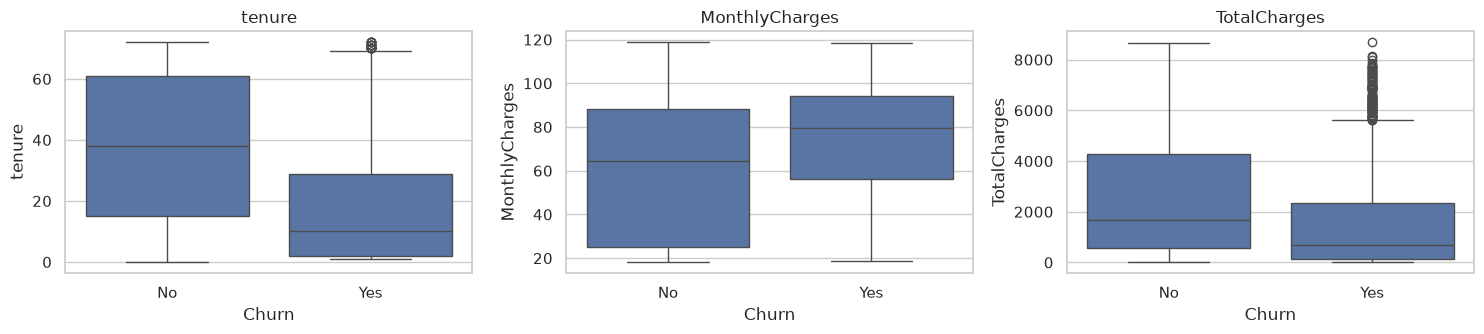

tenure            0
MonthlyCharges    0
TotalCharges      0
Name: IQR-rule outliers, dtype: int64

In [11]:
# Potential outliers: boxplots + IQR rule count
fig, axes = plt.subplots(1, 3, figsize=(15, 3.5))
for ax, col in zip(axes, num_cols):
    sns.boxplot(data=eda, x=TARGET, y=col, order=["No", "Yes"], ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()


def iqr_outlier_count(s):
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    return int(((s < q1 - 1.5 * iqr) | (s > q3 + 1.5 * iqr)).sum())


pd.Series({c: iqr_outlier_count(eda[c].dropna()) for c in num_cols}, name="IQR-rule outliers")

### 3.6 Categorical features (distribution and churn rate)

16 categorical features


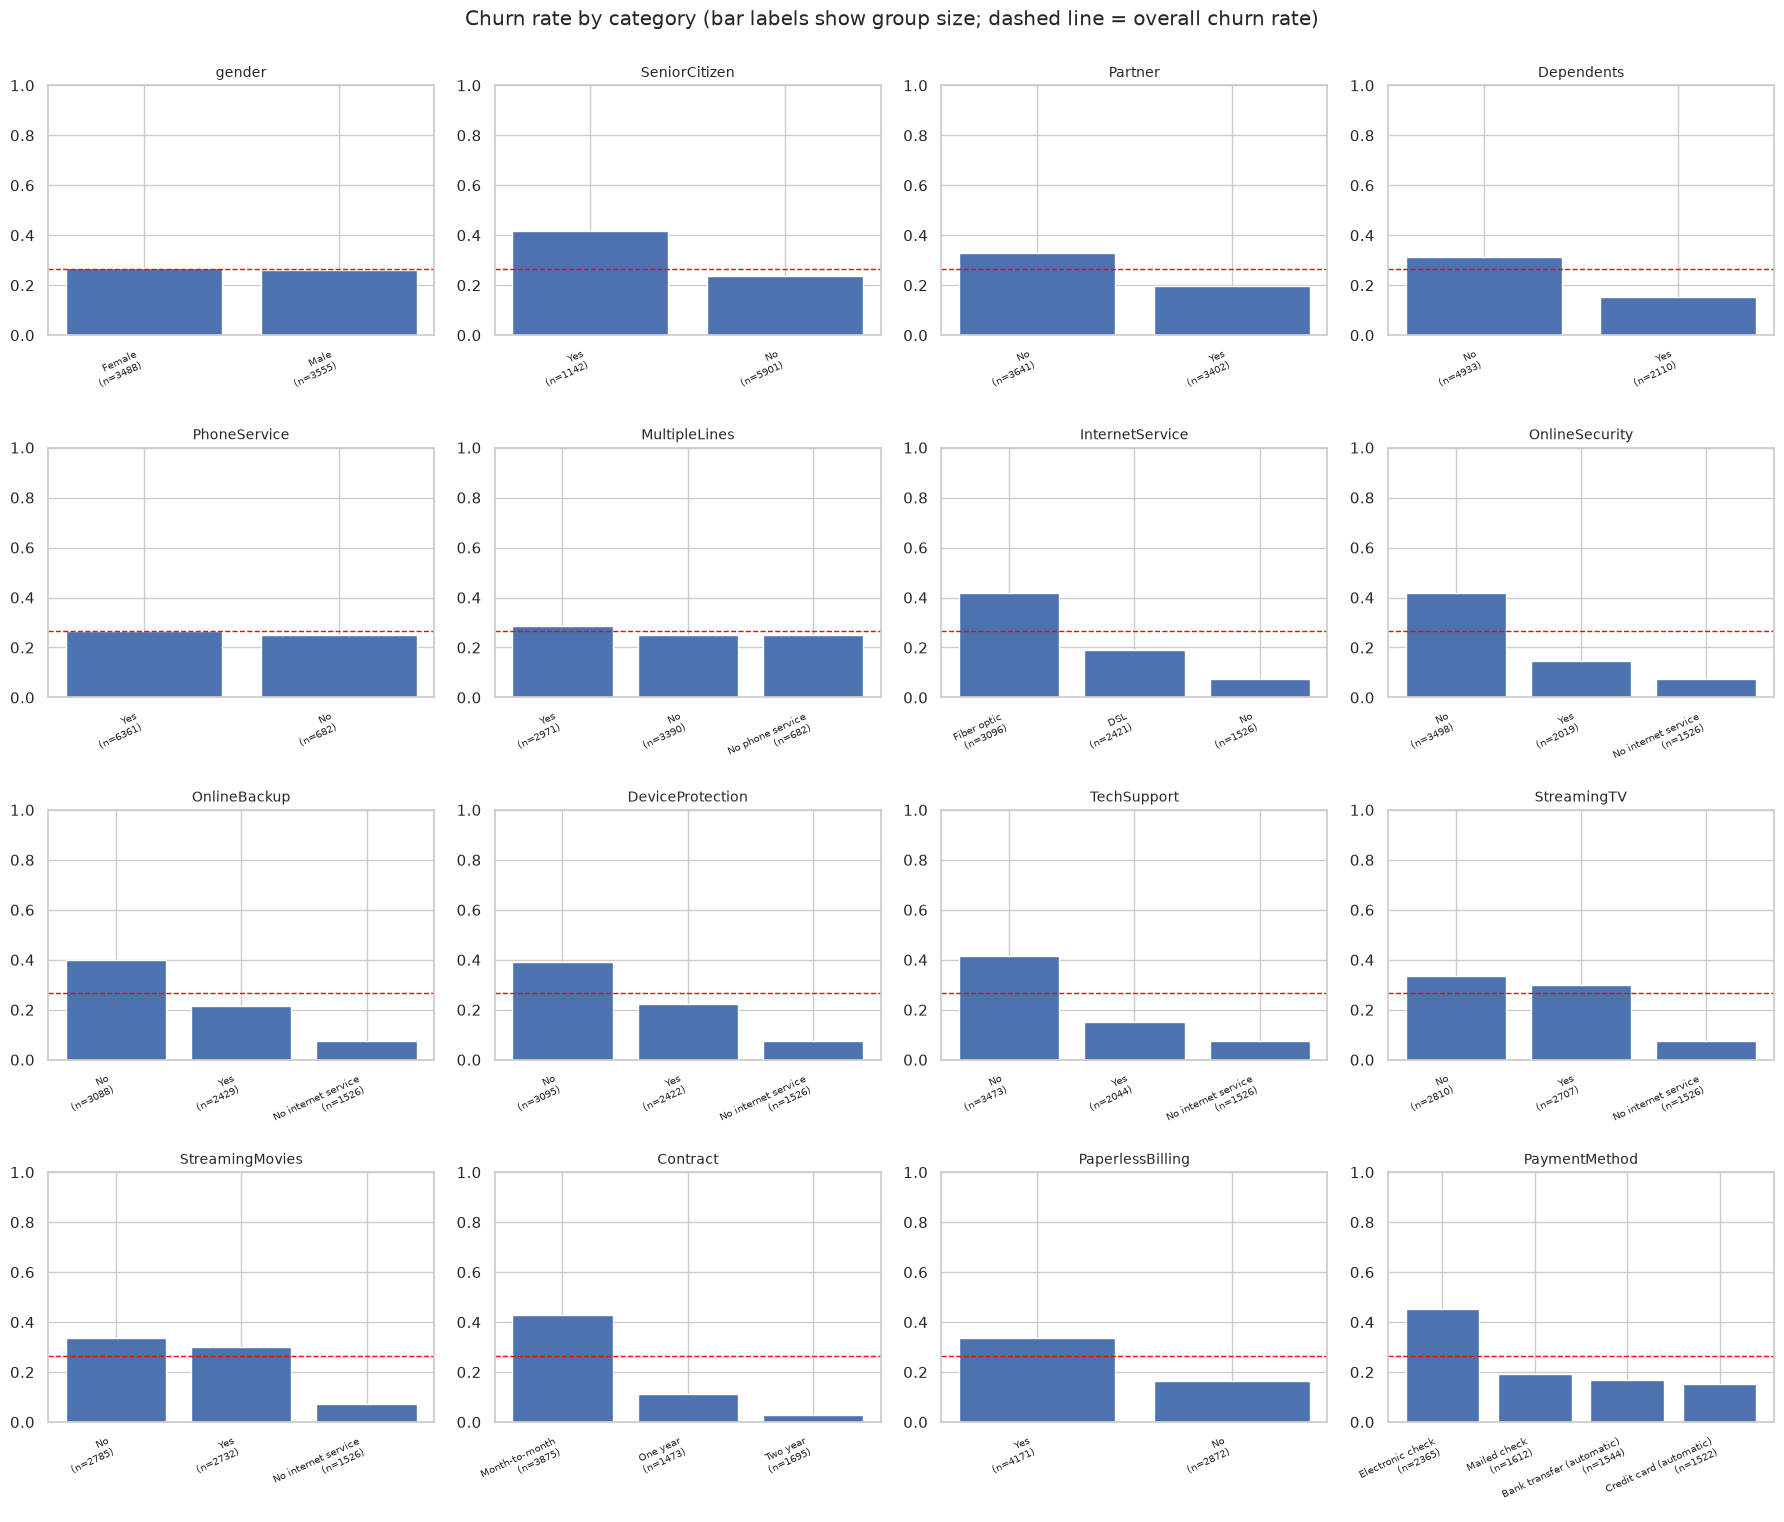

In [12]:
cat_cols = [c for c in eda.select_dtypes(exclude="number").columns if c not in (ID_COL, TARGET)]
print(len(cat_cols), "categorical features")

overall_rate = eda["churn_flag"].mean()
ncols = 4
nrows = int(np.ceil(len(cat_cols) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(18, 3.8 * nrows))
axes = axes.ravel()
for ax, c in zip(axes, cat_cols):
    g = eda.groupby(c)["churn_flag"].agg(["mean", "size"]).sort_values("mean", ascending=False)
    ax.bar(range(len(g)), g["mean"])
    ax.set_xticks(range(len(g)))
    ax.set_xticklabels([f"{i}\n(n={n})" for i, n in zip(g.index, g["size"])], fontsize=7, rotation=25, ha="right")
    ax.axhline(overall_rate, color="red", linestyle="--", linewidth=1)
    ax.set_ylim(0, 1)
    ax.set_title(c, fontsize=10)
for ax in axes[len(cat_cols):]:
    ax.axis("off")
fig.suptitle("Churn rate by category (bar labels show group size; dashed line = overall churn rate)", y=1.0)
plt.tight_layout()
plt.show()

### 3.7 Relationships with the target, and redundancy between features

Correlation of numeric features with churn flag:


tenure           -0.352
MonthlyCharges    0.193
TotalCharges     -0.199
Name: churn_flag, dtype: float64

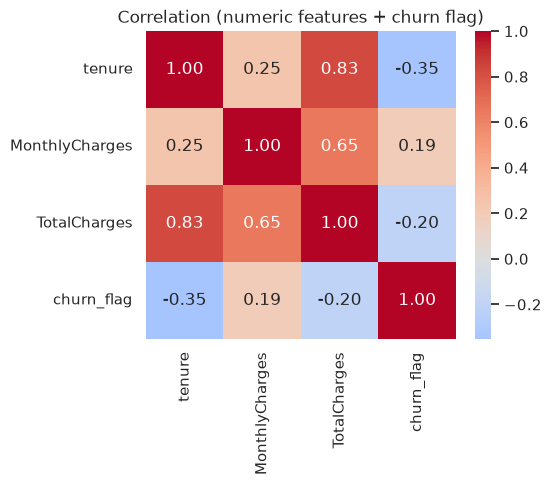

,churn_rate,n
tenure,,
0-6,0.529,1481
7-12,0.359,705
13-24,0.287,1024
25-48,0.204,1594
49-72,0.095,2239


corr(TotalCharges, tenure x MonthlyCharges): 1.0
customerID: 7043 unique values in 7043 rows


In [13]:
print("Correlation of numeric features with churn flag:")
display(eda[num_cols + ["churn_flag"]].corr()["churn_flag"].drop("churn_flag").round(3))

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(eda[num_cols + ["churn_flag"]].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlation (numeric features + churn flag)")
plt.show()

tenure_bins = pd.cut(eda["tenure"], [-1, 6, 12, 24, 48, 72], labels=["0-6", "7-12", "13-24", "25-48", "49-72"])
display(eda.groupby(tenure_bins, observed=True)["churn_flag"].agg(churn_rate="mean", n="size").round(3))

print("corr(TotalCharges, tenure x MonthlyCharges):",
      round(eda["TotalCharges"].corr(eda["tenure"] * eda["MonthlyCharges"]), 3))
print(f"{ID_COL}: {raw[ID_COL].nunique()} unique values in {len(raw)} rows")

## 4. EDA Findings
your own outputs, fill in the Evidence column with your numbers, and delete or add rows as needed.

| Finding (confirm from your output) | Evidence (fill in) | Why it matters | Action |
| --- | --- | --- | --- |
| Target classes are imbalanced | churn share = 26.5 % | Accuracy can look good while missing most churners | Stratify the split; report precision, recall, F1, ROC-AUC, PR-AUC and the confusion matrix |
| `TotalCharges` is stored as text with blank/unparsable entries | 1481 rows; their tenure = 0-6 | Text dtype breaks numeric processing; blanks may be brand-new customers who have not been billed | Convert to numeric; set to 0 only where `tenure == 0`; impute anything else inside the pipeline |
| `customerID` is unique for every row | 7043 unique of 7043 rows | An identifier carries no generalisable signal and can let a model memorise rows | Exclude from `X` |
| Tenure and contract type differ visibly between churners and non-churners | churn rate by tenure bin / contract = ___ | Likely strong signals a baseline should pick up | Keep; no action needed now |
| `TotalCharges` is closely tied to `tenure × MonthlyCharges` | correlation = 1.0 | Multicollinearity makes linear-model coefficients harder to interpret | Keep for the baseline; revisit in feature engineering |
| "No internet service" / "No phone service" categories repeat information already in `InternetService` / `PhoneService` | ___ | Redundant one-hot columns | Keep for the baseline; consider consolidating later |
| Duplicates / other missing values | ___ | Duplicates can leak between train and test | Handled in cleaning (Section 5) |

## 5. Data Cleaning
All cleaning here is **rule-based** (no statistic is estimated from the data), so it is safe to do before the split.
Anything that learns from data (median imputation, scaling, encoding) happens later inside the pipeline, fitted on training data only.
The logic lives in `src/data_preparation.py::clean`.

| Issue | Decision | Reasoning | Trade-off |
| --- | --- | --- | --- |
| Whitespace / blank strings | Strip text; blanks become missing | Blank strings hide missing values from `isna()` | None significant |
| `TotalCharges` stored as text | Convert to numeric (`errors="coerce"`) | It is a monetary amount | Any non-numeric value silently becomes NaN, so the log reports how many |
| `TotalCharges` missing where `tenure == 0` | Set to 0 | A customer with no tenure has not been billed yet | Assumes this explanation is right; the check below verifies it in your data |
| `TotalCharges` missing elsewhere (if any) | Leave as NaN; median-impute in the pipeline | Imputation statistics must come from training data only | Slight distortion if many are missing |
| `SeniorCitizen` coded 0/1 | Recode to No/Yes | Consistent handling with the other binary flags | None |
| Exact duplicate rows | Drop | Duplicates can appear in both train and test | Would remove genuine repeat rows, but exact matches including the ID are unlikely to be genuine |
| Missing/invalid target | Drop rows | Unusable for supervised learning | Loses those rows |
| Outliers | **Not** removed | Charges are bounded, plausible business values; a linear baseline with scaling tolerates them | Revisit if the boxplots show impossible values |

In [14]:
clean_df, cleaning_log = clean(raw)
display(pd.Series(cleaning_log, name="cleaning log").to_frame())

# Verify the assumption behind the tenure == 0 rule with YOUR data
was_bad = pd.to_numeric(raw["TotalCharges"], errors="coerce").isna()
print("Rows with non-numeric TotalCharges in raw data:", int(was_bad.sum()))
print("...of which have tenure == 0:", int((raw.loc[was_bad, "tenure"] == 0).sum()))
print("Missing values left after cleaning:", int(clean_df.isna().sum().sum()))
print("Shape raw -> clean:", raw.shape, "->", clean_df.shape)
clean_df.dtypes

,cleaning log
rows_in,7043
missing_before_conversion,11
totalcharges_blank_or_missing_in_raw,11
totalcharges_other_non_numeric_coerced,0
totalcharges_filled_with_0_tenure0,11
totalcharges_missing_left_for_pipeline,0
negative_numeric_values,0
duplicate_rows_dropped,0
rows_dropped_invalid_target,0
rows_out,7043


Rows with non-numeric TotalCharges in raw data: 11
...of which have tenure == 0: 11
Missing values left after cleaning: 0
Shape raw -> clean: (7043, 21) -> (7043, 21)


customerID           object
gender               object
SeniorCitizen           str
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object

In [15]:
out_path = save_processed(clean_df)
print("Saved cleaned data to", out_path)

Saved cleaned data to /workspaces/Customer-Churn-Prediction-02-Feature-Engineering/data/processed/telco_churn_clean.csv


## 6. Feature & Target Preparation
* `y` = 1 if `Churn == "Yes"` else 0. This matches the business question ("will this customer leave?") and makes churn the positive class.
* `X` = every column except `Churn` and `customerID`.

**Target-leakage review (reasoning):** every remaining feature must be known *before* the customer churns. The account and service attributes
qualify under the dataset's documented meaning, but confirm this against the column descriptions of your file. Columns such as `Churn Label`,
`Churn Score` or `Churn Reason` (present in some expanded versions) would leak the outcome and are dropped by `make_xy` if found.
A data-based leakage screen on the training set follows in Section 7.

In [16]:
X, y = make_xy(clean_df)
print("X:", X.shape, "| y:", y.shape)
print(y.value_counts().rename({0: "stayed", 1: "churned"}))
X.columns.tolist()

X: (7043, 19) | y: (7043,)
churn
stayed     5174
churned    1869
Name: count, dtype: int64


['gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'tenure',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'MonthlyCharges',
 'TotalCharges']

## 7. Train/Test Split
* **80/20 split, stratified on `y`**, with a fixed seed. Stratification keeps the churn share the same in both sets, which matters for an imbalanced target and makes the test metrics comparable to the training ones.
* The split happens **before** any imputation, scaling or encoding is fitted.
* The **test set is used once**, at the end (Section 10). All model comparison inside this milestone uses cross-validation on the training set.

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, stratify=y, random_state=RANDOM_STATE
)
pd.DataFrame(
    {"rows": [len(y_train), len(y_test)], "churn_rate": [y_train.mean(), y_test.mean()]},
    index=["train", "test"],
).round(3)

,rows,churn_rate
train,5634,0.265
test,1409,0.265


In [18]:
# Leakage screen on TRAINING data only (a diagnostic; it must not be used to tune features on the test set).
# Suspiciously "perfect" features can indicate information that would not exist at prediction time.
train_df = X_train.assign(churn=y_train)
pure = []
for c in X_train.select_dtypes(exclude="number").columns:
    g = train_df.groupby(c)["churn"].agg(["mean", "size"])
    if ((g["size"] >= 30) & ((g["mean"] == 0) | (g["mean"] == 1))).any():
        pure.append(c)
print("Categorical features with a category (n >= 30) that is 100% or 0% churn:", pure)

num_train = X_train.select_dtypes(include="number")
single_feature_auc = {}
for c in num_train.columns:
    a = roc_auc_score(y_train, num_train[c].fillna(num_train[c].median()))
    single_feature_auc[c] = max(a, 1 - a)
print("Single-feature ROC-AUC (numeric):", {k: round(v, 3) for k, v in single_feature_auc.items()})

Categorical features with a category (n >= 30) that is 100% or 0% churn: []
Single-feature ROC-AUC (numeric): {'tenure': 0.735, 'MonthlyCharges': 0.624, 'TotalCharges': 0.645}


## 8. Preprocessing Pipeline
Implemented in `src/preprocessing.py` as a `ColumnTransformer`:

| Feature group | Steps |
| --- | --- |
| Numeric | median imputation → standard scaling |
| Categorical | most-frequent imputation → one-hot encoding (`handle_unknown="ignore"`) |

**How leakage is avoided:** the transformer is *unfitted* until it is part of a `Pipeline` that is fitted on training data. Medians, means/standard
deviations and the category lists are learned from the training rows only. During cross-validation the whole pipeline is re-fitted inside each fold,
and at test time the already-fitted pipeline only *transforms*.

In [19]:
numeric_cols, categorical_cols = split_column_types(X_train)
print("Numeric:", numeric_cols)
print("Categorical:", len(categorical_cols), "columns")

preprocessor = build_preprocessor(X_train)
preprocessor

Numeric: ['tenure', 'MonthlyCharges', 'TotalCharges']
Categorical: 16 columns


,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``

In [20]:
# Sanity check on a throw-away copy: fit on TRAIN only, then transform TRAIN and TEST
check = build_preprocessor(X_train).fit(X_train)
print("Transformed train shape:", check.transform(X_train).shape)
print("Transformed test shape :", check.transform(X_test).shape)
print("Number of output features:", len(check.get_feature_names_out()))

Transformed train shape: (5634, 46)
Transformed test shape : (1409, 46)
Number of output features: 46


## 9. Baseline Model
* **Reference floor — `DummyClassifier` (class prior):** always predicts the majority class. Any real model must beat it; it also shows how misleading accuracy is under imbalance.
* **Baseline model — Logistic Regression** (default regularisation, no class weights, no tuning): simple, fast, well-understood, works with a standardised + one-hot feature matrix, and
  outputs probabilities that support ROC-AUC. Its coefficients are also interpretable.

Deliberately **not** done here: hyperparameter tuning, class weighting, threshold tuning, other model families (reserved for later milestones).

Both models are first compared with stratified 5-fold cross-validation on the **training set only**.

In [21]:
dummy = build_dummy_baseline(X_train)
logreg = build_logistic_baseline(X_train)

cv_dummy = cross_validate_on_train(dummy, X_train, y_train)
cv_logreg = cross_validate_on_train(logreg, X_train, y_train)

print("Cross-validation on training data - Dummy (majority class)")
display(cv_dummy.round(3))
print("Cross-validation on training data - Logistic Regression")
display(cv_logreg.round(3))

Cross-validation on training data - Dummy (majority class)


,mean,std
accuracy,0.735,0.0
precision,0.000,0.0
recall,0.000,0.0
f1,0.000,0.0
roc_auc,0.500,0.0
pr_auc,0.265,0.0


Cross-validation on training data - Logistic Regression


,mean,std
accuracy,0.802,0.012
precision,0.652,0.026
recall,0.544,0.041
f1,0.592,0.030
roc_auc,0.846,0.013
pr_auc,0.661,0.019


## 10. Baseline Evaluation
Now the models are fitted on the full training set and evaluated **once** on the held-out test set. Threshold = 0.5 (default); it is not tuned in this milestone.

What each metric means for churn:

| Metric | Meaning in this project |
| --- | --- |
| Accuracy | Share of all customers classified correctly. Misleading with imbalance: predicting "stays" for everyone already scores high |
| Precision | Of customers flagged as likely churners, the share who really churn (low precision = wasted retention offers) |
| Recall | Of customers who really churn, the share we catch (low recall = churners we miss and lose) |
| F1-score | Harmonic mean of precision and recall at the 0.5 threshold |
| ROC-AUC | Probability that a random churner is ranked above a random non-churner; threshold-independent ranking quality (0.5 = chance) |
| PR-AUC | Area under the precision-recall curve; more informative than ROC-AUC when the positive class is the minority |
| Confusion matrix | Counts of true/false positives and negatives, showing *which* mistakes are made |

In [22]:
dummy.fit(X_train, y_train)
logreg.fit(X_train, y_train)

dummy_metrics, _, _ = evaluate_on(dummy, X_test, y_test)
test_metrics, y_pred, y_proba = evaluate_on(logreg, X_test, y_test)

results = pd.DataFrame({"Dummy (majority)": dummy_metrics, "Logistic Regression": test_metrics}).round(3)
results.index.name = "Metric (test set)"
results

,Dummy (majority),Logistic Regression
Metric (test set),,
accuracy,0.735,0.806
precision,0.000,0.657
recall,0.000,0.559
f1,0.000,0.604
roc_auc,0.500,0.842
pr_auc,0.265,0.634


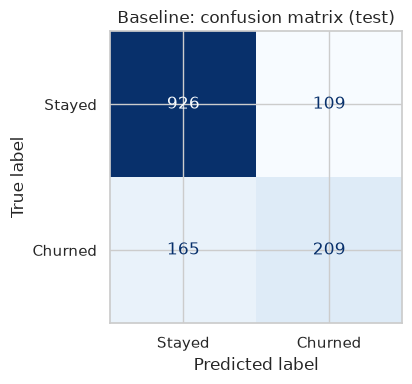

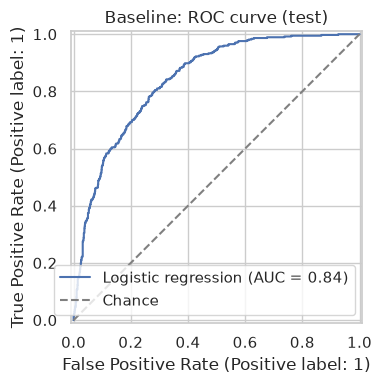

In [23]:
fig1 = plot_confusion_matrix(y_test, y_pred, "Baseline: confusion matrix (test)")
fig2 = plot_roc(y_test, y_proba, "Baseline: ROC curve (test)")
plt.show()

In [24]:
print(classification_report(y_test, y_pred, target_names=["Stayed", "Churned"], zero_division=0))

              precision    recall  f1-score   support

      Stayed       0.85      0.89      0.87      1035
     Churned       0.66      0.56      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



## 11. Baseline Interpretation
The coefficients below come from the model fitted on the **training** set. They are descriptive only: features are standardised/one-hot encoded, and correlated
features (e.g. `TotalCharges` with `tenure`, or the redundant "No internet service" categories) share credit, so treat the ranking as a rough guide, not causal evidence.

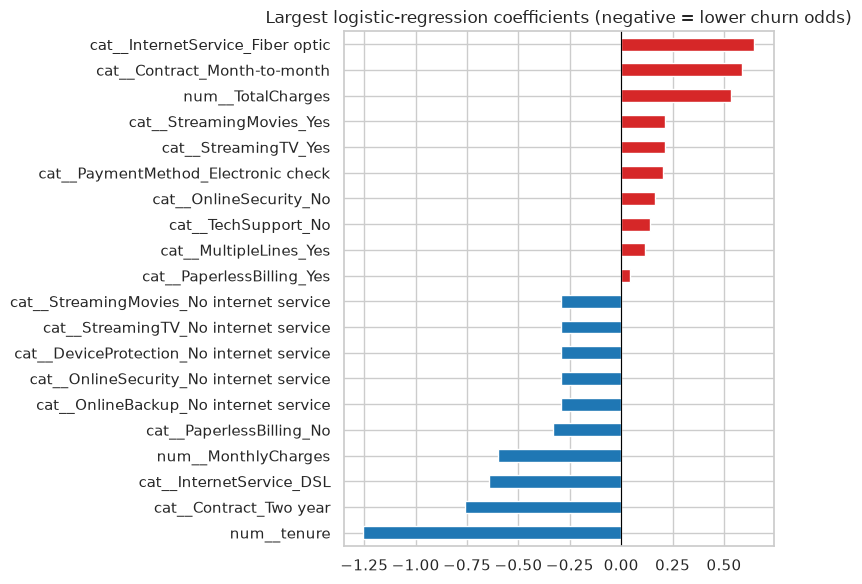

In [25]:
feature_names = logreg.named_steps["preprocess"].get_feature_names_out()
coefs = pd.Series(logreg.named_steps["model"].coef_[0], index=feature_names).sort_values()
top = pd.concat([coefs.head(10), coefs.tail(10)])

fig, ax = plt.subplots(figsize=(8, 6))
top.plot.barh(ax=ax, color=["tab:blue" if v < 0 else "tab:red" for v in top])
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Largest logistic-regression coefficients (negative = lower churn odds)")
plt.tight_layout()
plt.show()

## 12. Risks & Limitations
* **Data:** a public, IBM-generated sample dataset — it may not reflect real telecom churn behaviour, and the exact rows/columns depend on the version you downloaded.
* **Snapshot data:** no timestamps, so a time-based split (train on the past, test on the future) is impossible; the model cannot be checked for drift.
* **Potential leakage:** no obvious post-churn columns in the standard 21-column file, but this is a judgement based on documentation; the expanded versions do contain leaking columns.
* **Class imbalance:** the minority (churn) class limits how well recall and precision can both be high; accuracy is not a reliable headline metric.
* **Sampling:** unknown how customers were selected; results may not transfer to other regions, plans or time periods.
* **Modelling:** a single, untuned linear model at a default 0.5 threshold; no interaction terms; no class weighting.
* **Evaluation:** one 80/20 split gives a single point estimate; with ~1,400 test rows (if you use the standard file) the metrics carry noticeable uncertainty. Cross-validation on train helps quantify that.

## 13. Next-Milestone Direction
Ideas to consider later (not done here): class weighting or resampling; threshold selection based on retention-offer cost; regularisation-strength tuning; tree-based models
(random forest, gradient boosting) to capture interactions; feature engineering (e.g. number of add-on services, tenure buckets, charge-per-month ratios); probability calibration;
cost-sensitive evaluation; and more robust evaluation (repeated CV, confidence intervals).

## 14–15. Repository Structure & README
See the repository root: `README.md` documents the structure, setup, how to reproduce the baseline (`python -m src.train_baseline`).